**Growing and Visualizing a Tree**
- **Dataset:** from sklearn.datasets import fetch_openml
- **Task:** Train a Decision Tree classifier on a tabular dataset containing categorical and numerical data (like the Titanic dataset, after basic cleaning).
- **Action:** Use sklearn.tree.plot_tree or export the model using graphviz to generate a visual flowchart of the tree. Trace the path of a specific passenger to see exactly why the model predicted they survived or died.

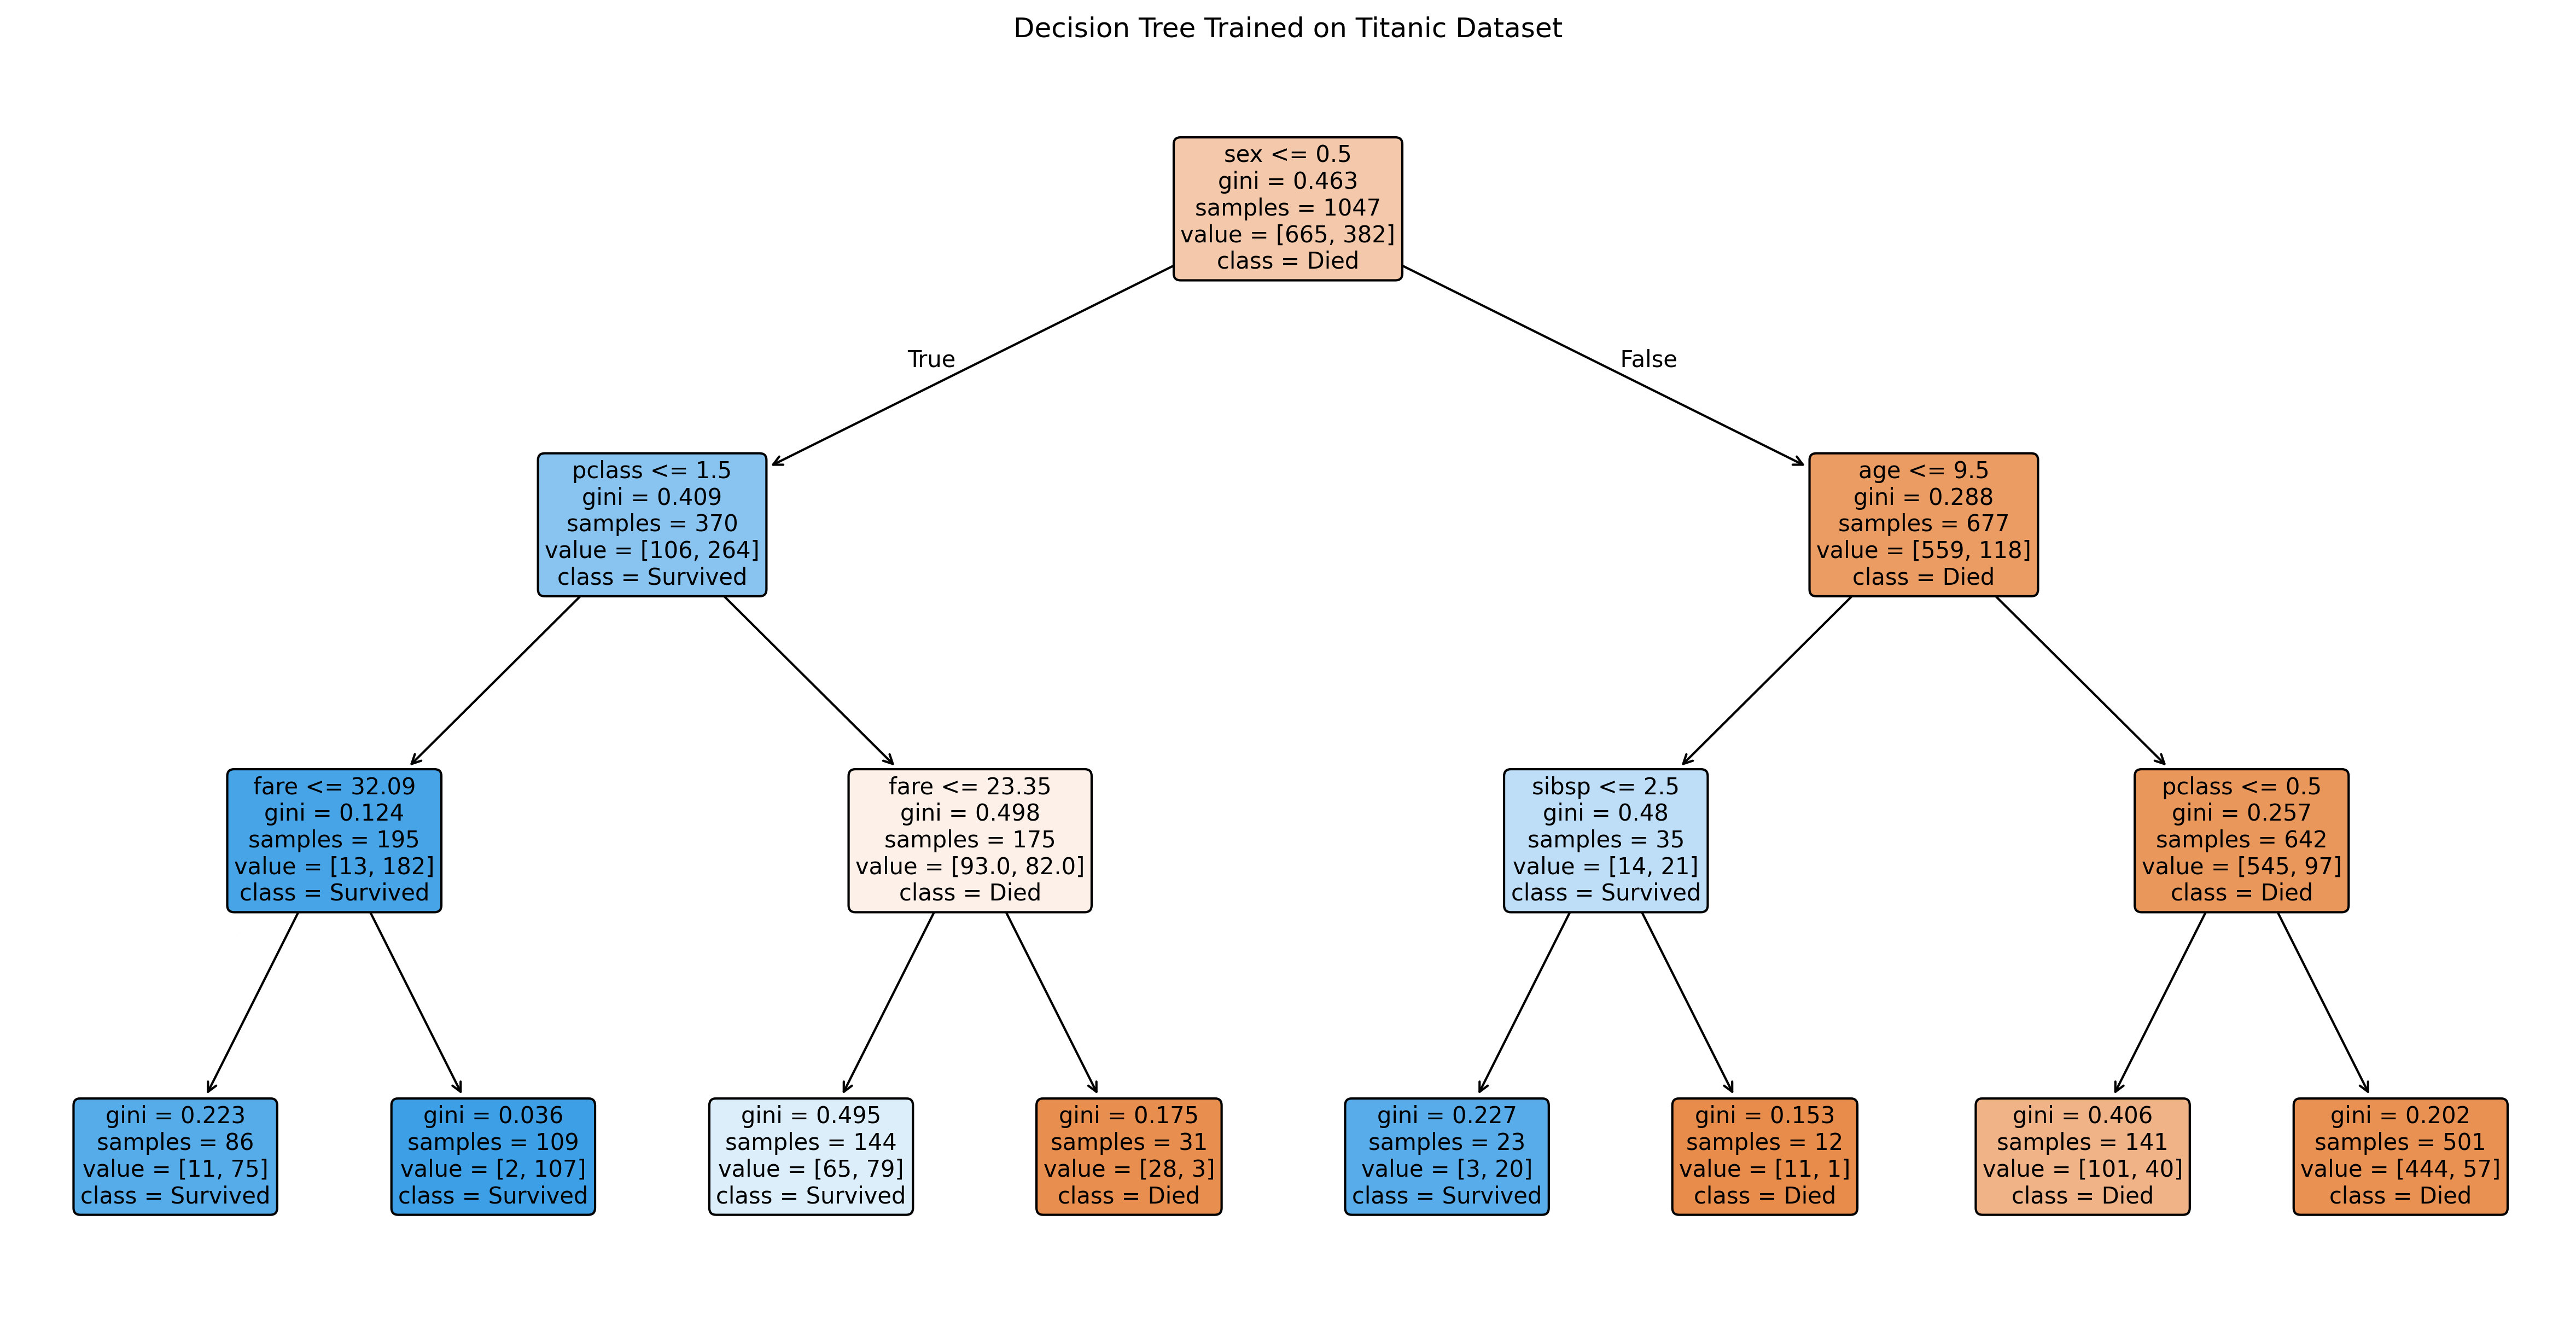

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# 1. Fetch the Titanic dataset
titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
df = titanic.frame

# Select a subset of clean, interpretable features
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
X = df[features].copy()
y = df['survived'].astype(int)

# 2. Define preprocessing pipelines
numerical_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'pclass']

num_transformer = SimpleImputer(strategy='median')
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder()) # Ordinal keeps feature space 1:1 for easy tracing
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, numerical_features),
    ('cat', cat_transformer, categorical_features)
])

# 3. Create and train the pipeline with a shallow tree for visualization clarity
clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(max_depth=3, random_state=42))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)

# Get feature names in order of the preprocessed output
encoded_feature_names = numerical_features + categorical_features

plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    clf.named_steps['classifier'],
    feature_names=encoded_feature_names,
    class_names=['Died', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Trained on Titanic Dataset")
plt.show()

**Pruning and Overfitting Mitigation**
- **Dataset:** from sklearn.datasets import fetch_openml
- **Task:** Decision trees naturally overfit. Train an unconstrained decision tree on a complex dataset and note the training accuracy (often 100%) vs. test accuracy.
- **Action:** Experiment with hyperparameter tuning to "prune" the tree. Specifically, tweak max_depth, min_samples_split, and min_samples_leaf. Find the combination that reduces the gap between training and test accuracy, yielding a more generalized model.

In [4]:
import pandas as pd
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load Titanic dataset
titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
df = titanic.frame

# Features and target
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
X = df[features].copy()
y = df['survived'].astype(int)

# Preprocessing
numerical_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['sex', 'pclass']

preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), numerical_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder())
    ]), categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train an unconstrained tree
overfit_clf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42)) # No limits set
])

overfit_clf.fit(X_train, y_train)

# Check performance
train_acc = overfit_clf.score(X_train, y_train)
test_acc = overfit_clf.score(X_test, y_test)

print("--- Unconstrained Tree Baseline ---")
print(f"Training Accuracy: {train_acc * 100:.2f}%")
print(f"Test Accuracy:     {test_acc * 100:.2f}%")
print(f"Generalization Gap: {(train_acc - test_acc) * 100:.2f}%")

--- Unconstrained Tree Baseline ---
Training Accuracy: 96.94%
Test Accuracy:     76.72%
Generalization Gap: 20.23%
